<a href="https://colab.research.google.com/github/mekaeli/ELE767_CODES/blob/main/Laboratoire_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Segment de codes 1
def nom_de_la_fonction(argument1, argument2 =" valeur par defaut "):
    pass

"""
NOM_DE_LA_FONCTION # en majuscule
breve description de la fonction
@Arguments :
argument1 { type voulu pour l’argument1 } : description de ce que doit etre l
’argument1
argument2 { type voulu pour l’argument2 } : description de ce que doit etre l
’argument2
# ( facultatif ) explication du choix pour la valeur par defaut
@Return :
{ type de l’objet retourne par la fonction } : description de l’objet
retourne par la fonction
# Si d’autres objets sont retournes , la meme syntaxe est utilisee pour
chaque objet .
( facultatif ) Note : Information qui peut etre importante a connaitre pour l’
utilisation de la fonction
"""


'\nNOM_DE_LA_FONCTION # en majuscule\nbreve description de la fonction\n@Arguments :\nargument1 { type voulu pour l’argument1 } : description de ce que doit etre l\n’argument1\nargument2 { type voulu pour l’argument2 } : description de ce que doit etre l\n’argument2\n# ( facultatif ) explication du choix pour la valeur par defaut\n@Return :\n{ type de l’objet retourne par la fonction } : description de l’objet\nretourne par la fonction\n# Si d’autres objets sont retournes , la meme syntaxe est utilisee pour\nchaque objet .\n( facultatif ) Note : Information qui peut etre importante a connaitre pour l’\nutilisation de la fonction\n'

In [ ]:
# Segment de codes 2
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import KFold
# Pour l’affichage des figures sans plt . show ()
%matplotlib inline

In [ ]:
# Segment de codes 3
!ls -lah

total 25M
drwxr-xr-x 1 root root 4.0K Mar  8 09:14 .
drwxr-xr-x 1 root root 4.0K Mar  8 09:08 ..
drwxr-xr-x 4 root root 4.0K Jan 16 14:24 .config
-rw-r--r-- 1 root root  25M Mar  8 09:15 data.csv
-rw-r--r-- 1 root root 155K Mar  8 09:14 mystere.csv
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data


In [ ]:
# Segment de codes 4
# Transfert des datasets vers des variables ( DataFrames )
data_ds=pd.read_csv("data.csv")

In [ ]:
# Segment de codes 5
print (" __data__ ")
print ( data_ds . info ())
print ( data_ds . head ())
print ( data_ds . tail ())




 __data__ 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890 entries, 0 to 889
Columns: 1561 entries, W0_MS_0 to number
dtypes: float64(1560), int64(1)
memory usage: 10.6 MB
None
    W0_MS_0   W0_MS_1   W0_MS_2   W0_MS_3   W0_MS_4   W0_MS_5   W0_MS_6  \
0  1.011981  2.142074  0.588728 -0.692308 -0.203841  1.042901 -0.537213   
1  0.083026  2.450909  0.818768  3.092884 -0.610867  4.112420  0.218586   
2  0.127918  1.936767  0.395461  1.011786 -0.208603  0.058295 -0.453895   
3  0.673839  1.831173  2.084694  0.548835 -0.690189  0.056046  0.763344   
4  2.182024 -0.060605 -0.000992  1.056996 -0.412494 -0.210797  1.100925   

    W0_MS_7   W0_MS_8   W0_MS_9  ...  W59_MD_4  W59_MD_5  W59_MD_6  W59_MD_7  \
0  0.498876 -0.680100 -0.737847  ...  0.581696 -0.422061 -0.210426 -0.492524   
1  0.147865  0.820458  1.024225  ... -0.554939 -0.722586 -0.363003 -0.661282   
2  1.157127 -0.097942  1.268917  ... -0.578180 -0.587715 -0.715070 -0.785123   
3 -0.764594 -0.405546  0.371929  ... -0.697126

In [ ]:
# Segment de codes 6
def create_sets( data_ds , n_fold =5) :
  """
  CREATE_SETS
  Transforme les bases de donnees afin d’etre compatible avec l’ entrainement
  du modele avec la methode " fit "
  @Arguments :
  data_ds {pd. DataFrame } : Base de donnees d’ entrainement
  n_fold { int } : nombre de division pour le kfold
  @Return :
  { tensorflow . BatchDataset } : Base de donnees d’ entrainement
  { tensorflow . BatchDataset } : Base de donnees de test
  """
  # Melanger les valeurs de la base de donnees
  data = data_ds . sample ( frac =1) . reset_index ( drop = True )

  # Diviser les variables et les resultats
  data_output = data . pop("number")

  # Extraire les indexes pour le kfold une seule fois
  for train_index , test_index in KFold ( n_fold ). split ( data ) :
    # Creer la base de donnees d’ entrainement
    X_train = ( data . values )[ train_index ]
    y_train = ( data_output . values )[ train_index ]

    ### Creer la base de donnees de test
    X_test = ( data . values )[ test_index ]
    y_test = ( data_output . values )[ test_index ]
    break

  # Transformer les bases de donnees pour etre utilisees directement dans fit
  # Les donnees sont melangees une autre fois avant d’etre retournees
  train_set = tf. data . Dataset . from_tensor_slices (( X_train , y_train ))
  train_set = train_set . shuffle ( len ( X_train ))
  train_set = train_set . batch (1)

  test_set = tf. data . Dataset . from_tensor_slices (( X_test , y_test ))
  test_set = test_set . shuffle (len ( X_test ))
  test_set = test_set . batch (1)

  return train_set, test_set

In [ ]:
# Segment de codes 7
# Creer un modele sequentiel
perceptron = tf.keras.Sequential([
  layers.Dense(4, activation='sigmoid', dtype='float64')
])
# Compiler le modele pour l’entrainement
perceptron.compile(optimizer='SGD',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                metrics=['accuracy'])

In [ ]:
def training(model, data_ds, epochs=10, n_fold=5, verbose_train=1, verbose_test=1):
    """
    TRAINING

    Fonction servant a entrainer un model et en verifiant les capacites du modele sur les donnees de test

    @Arguments :
        model {tensorflow.python.keras.engine.sequential.Sequential} : Modele   tensorflow a entrainer
        data_ds {pd.DataFrame} : Base de données d'entrainement
        epochs {int} : Nombre d'epoques a faire pour l'entrainement du model
        n_fold {int} : Nombre de fold pour le kfold
        verbose_train {int} : 1 pour afficher l'avancement de l'apprentissage,  0 aucun affichage
        verbose_test {int} : 1 pour afficher l'avancement de l'evaluation, 0 aucun affichage

    @Return :
        {dict} :'train_accuracy' {list} : precision du modele sur la base d'entrainement
        'train_loss' {list} : perte du modele sur la base d'entrainement
        'test_accuracy' {list} : precision du modele sur la base de test
        'test_loss' {list} : perte du modele sur la base de test
    """
    # Initialisation des listes recevants
    train_accuracy = []
    train_loss = []
    test_accuracy = []
    test_loss = []

    # Creer les bases de donnees pour l'entrainement
    train_set, test_set = create_sets(data_ds, n_fold)

    # Evaluer le modele avant l'entrainement
    result = model.evaluate(train_set, verbose=verbose_train)
    train_accuracy.append(result[1])
    train_loss.append(result[0])

    result = model.evaluate(test_set, verbose=verbose_test)
    test_accuracy.append(result[1])
    test_loss.append(result[0])

    # Boucle d'entrainement
    for e in range(epochs):
        print('Epoch #{}'.format(e + 1))

        result = model.fit(train_set, epochs=1, verbose=verbose_train)
        train_accuracy.append(result.history['accuracy'][-1])
        train_loss.append(result.history['loss'][-1])

        result = model.evaluate(test_set, verbose=verbose_test)
        test_accuracy.append(result[1])
        test_loss.append(result[0])

    return {
        'train_accuracy': train_accuracy,
        'train_loss': train_loss,
        'test_accuracy': test_accuracy,
        'test_loss': test_loss
    }

In [ ]:
# Segment de codes 9
def figure (training_dict , suptitle , figsize =(12 ,6)):
    """
    FIGURE
    Produit une figure avec les statistiques de la fonction 'training '
    @Arguments :
    training_dict { dict ( list )} : Dictionnaire retournee par la fonction
    training
    figsize { Tuple } : Dimension de la figure
    """
    # Demarre une figure avec la taille (en pouce ) donner en arguments
    plt.figure(figsize = figsize , facecolor ='w')

    # Titre global de la figure
    plt . suptitle (suptitle)

    # Premiere sous - figure -> Precision du modele durant l' entrainement
    plt . subplot (121)
    plt . title ('Precision du modele')
    plt . xlabel ('Nombre d\' epoques')
    plt . ylabel ('Precision de la classification')
    # Produit une courbe pour chaque base de donnees
    plt . plot ( training_dict ['train_accuracy'], 'r', label ='training')
    plt . plot ( training_dict ['test_accuracy'], 'y', label ='test')
    # Limite de la precision pour rendre les valeurs entre 0% et 100% visibles
    plt . ylim (0 ,1.01)
    # Produire un grille en arriere - plan
    # plt . grid (True , which =' major ', color = '#666666 ' , linestyle ='-')
    plt . grid ()
    plt . minorticks_on ()
    plt . grid (True , which ='minor', color='#999999', linestyle ='-', alpha =0.2)
    plt . legend () # Afficher les labels des courbes

    # Deuxieme sous - figure -> Resultat de la fonction de perte durant l'entrainement
    plt . subplot (122)
    plt . title ('Perte du modele')
    plt . xlabel ('Nombre d\' epoques')
    plt . ylabel ('Resultat de la fonction de perte')
    # Produire une courbe pour chaque base de donnees
    plt . plot ( training_dict ['train_loss'],'r', label ='training')
    plt . plot ( training_dict ['test_loss'],'y', label ='test');
    # S'assurer que la valeur minimum de l'ordonnee soit 0
    plt . ylim (0) ;
    # Produire un grille en arriere - plan
    # plt . grid (True , which =' major ', color = '#666666 ' , linestyle ='-')
    plt . grid ()
    plt . minorticks_on ()
    plt . grid (True , which ='minor', color='#999999', linestyle ='-', alpha =0.2)
    plt . legend ()
    return

In [ ]:
# Segment de codes 10
result = training(perceptron, data_ds, epochs=25)

712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2364 - loss: 1.7463
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2854 - loss: 1.6087
Epoch #1
712/712 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5815 - loss: 1.0828
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8293 - loss: 0.4069
Epoch #2
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9214 - loss: 0.2372
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8631 - loss: 0.6846
Epoch #3
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9815 - loss: 0.0514
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8898 - loss: 0.4058
Epoch #4
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9836 - loss: 0.0399
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8896 - loss: 0.3808
Epoch #5
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9981 - loss: 0.0071
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8873 - loss: 0.4067
Epoch #6
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc

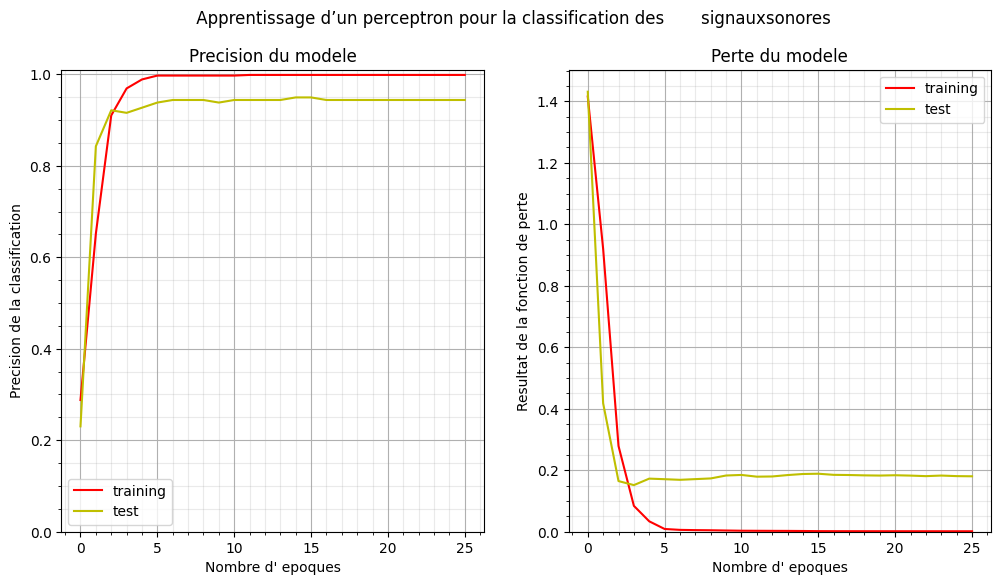

In [ ]:
# Segment de codes 11
figure(result, " Apprentissage d’un perceptron pour la classification des       signauxsonores")


In [141]:
# Segment de codes 12
perceptron.save('modeles/perceptron.keras')

In [143]:
# Segment de codes 13
mlp2c = tf.keras.Sequential([
    layers.Dense(512 , activation ='sigmoid', dtype ='float64'),
    layers.Dense (4, activation ='sigmoid', dtype ='float64')
])

# Compiler le modele pour l’ entrainement
mlp2c . compile ( optimizer ='SGD',
                 loss = tf.keras.losses.SparseCategoricalCrossentropy(),
metrics =['accuracy'])

In [149]:
# Segment de codes 14
# Creer une couche d’entree
# La dimension des Tensors utilises est de (None , 1, 1560)
model_input = layers.Input(shape =( None, 1, data_ds.shape [1] -1))

# Creer les couches du reseau de neurones
x = layers.Dense (512, activation ='sigmoid',dtype ='float64')(model_input )
model = layers . Dense (4, activation ='sigmoid', dtype ='float64')(x)

# Valider le modele
model = tf.keras.Model(model_input, model)

# Compiler le modele pour l’ entrainement
model.compile (optimizer ='SGD',
              loss = tf.keras.losses.SparseCategoricalCrossentropy() ,
              metrics =['accuracy'])